# EDA instructions and notes
- Finds main columns and columns included in the dataset.
- Finds class imbalance.
- Each image's bounding box is declared by 3 doctors, find the disagreement of the annotations.
- Bounding box distribution.

# Presiquitesets (IDK HOW TO SPellL)
make sure to install the dataset as instructed in README.md

In [13]:
# libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2


In [2]:
# directories and files
# notes: the relative path while runnign notebook filles is count from the running notebook
DATA_DIRECTORY = "../data/raw/"
TRAIN_CSV = os.path.join(DATA_DIRECTORY, "train.csv")
TRAIN_DIRECTORY = os.path.join(DATA_DIRECTORY, "train/")
TEST_DIRECTORY = os.path.join(DATA_DIRECTORY, "test/")

In [3]:
df = pd.read_csv(TRAIN_CSV)
df.head()

,Unnamed: 0,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,raw_x_min,raw_x_max,raw_y_min,raw_y_max,raw_width,raw_height,scale_x,scale_y
0,0,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
1,1,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
2,2,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
3,3,183015e171f5159d7e60d43578632a3f,Aortic enlargement,0,R8,567.0,295.0,671.0,417.0,1134.0,1342.0,721.0,1019.0,2048.0,2500.0,0.500000,0.409600
4,4,183015e171f5159d7e60d43578632a3f,Pleural thickening,11,R9,58.0,794.0,116.0,851.0,117.0,232.0,1938.0,2077.0,2048.0,2500.0,0.500000,0.409600


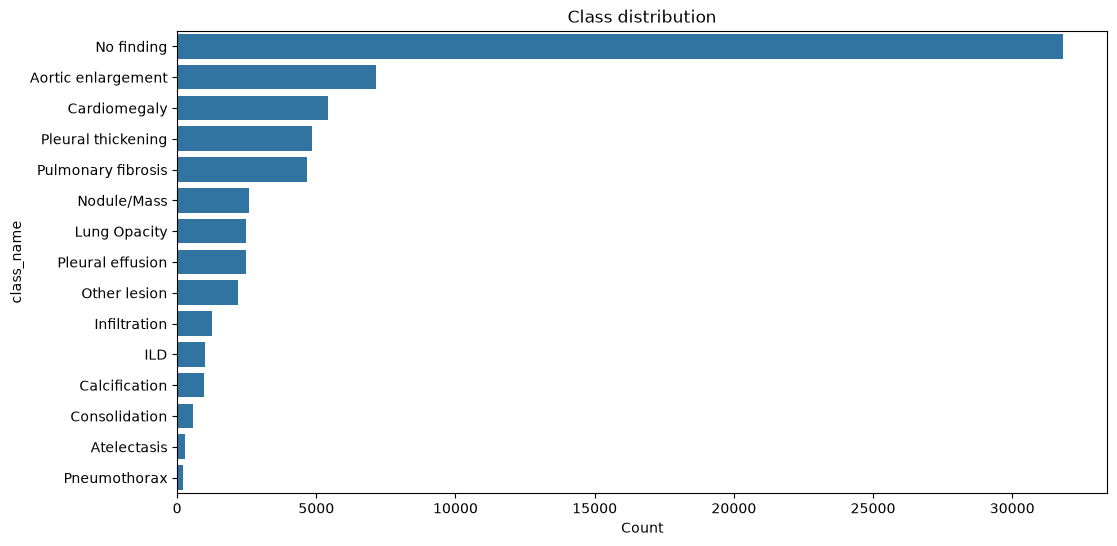

In [8]:
plt.figure(figsize=(12, 6))
class_counts = df["class_name"].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index)
plt.title("Class distribution")
plt.xlabel("Count")
plt.show()

In the result up there, "No finding" made a huge percentage on the distribution.

Now, we find the doctors' annotation from R1-R17.
- Radiologist ID (Rxx): an ID represent a doctor identity, like, who is responsible for the labeling of a specific image in the dataset.
- This is crucial for: Annotator bias and labeling noises

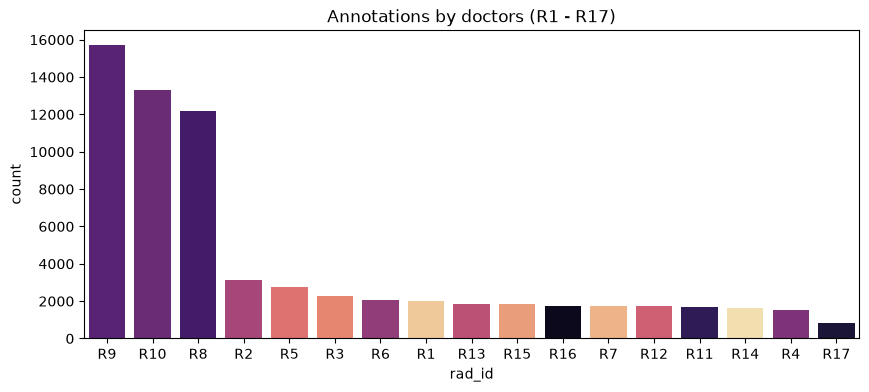

In [11]:
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df, 
    x="rad_id",
    hue="rad_id",
    legend=False, 
    order=df["rad_id"].value_counts().index, 
    palette="magma"
)
plt.title("Annotations by doctors (R1 - R17)")
plt.show()

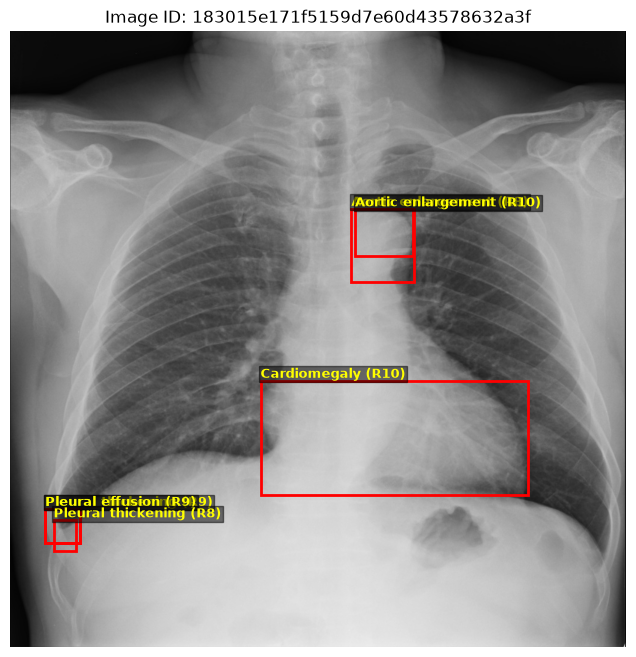

In [15]:
# function to display a specific image, with bounding boxes
def display(image_id, df, img_folder_dir):
    boxes = df[df["image_id"] == image_id]
    img_dir = os.path.join(img_folder_dir, f'{image_id}.jpg')
    img = cv2.imread(img_dir)
    if img is None:
        print(f"[ERROR] Image not found: {image_id}.jpg")
        return

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    for _, row in boxes.iterrows():
        if row["class_id"] == 14:
            continue
        
        x_min, y_min = row["x_min"], row["y_min"]
        w = row["x_max"] - row["x_min"]
        h = row["y_max"] - row["y_min"]

        rect = patches.Rectangle(
            (x_min, y_min),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x_min,
            max(0, y_min - 5),
            f"{row['class_name']} ({row['rad_id']})",
            color="yellow",
            fontsize=9,
            weight="bold",
            bbox=dict(facecolor="black", alpha=0.5, pad=1),
        )

    plt.title(f"Image ID: {image_id}")
    plt.axis("off")
    plt.show()

abnormal_samples = df[df["class_id"] != 14]["image_id"].values
if len(abnormal_samples) > 0:
    display(abnormal_samples[0], df, TRAIN_DIRECTORY)